In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import pandas as pd

import glob
import rasterio
import re
from collections import defaultdict



sys.path.append(os.path.abspath("..")) 
#from src.utils import load_config
#config = load_config()

In [2]:
def check_alignment(data_dict, product, tile):
    """
    Check if all rasters for a given product/tile are aligned.
    Returns True if aligned, else prints mismatches.
    """
    # Grab one reference profile
    dates = list(data_dict[product][tile].keys())
    ref_profile = data_dict[product][tile][dates[0]]["profile"]

    aligned = True
    for date, data in data_dict[product][tile].items():
        profile = data["profile"]

        # Compare critical fields
        for key in ["crs", "transform", "width", "height"]:
            if profile[key] != ref_profile[key]:
                print(f"Mismatch on {date}: {key} differs")
                aligned = False
    return aligned



In [6]:
check_alignment(data_dict, "FAPAR", "T31UFT")

True

In [3]:


def inspect_tiff(path, nan_color="red"):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)

        # Replace no-data values if rasterio defines them
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan

    # Compute stats
    nan_count = np.isnan(arr).sum()
    zero_count = np.sum(arr == 0)
    total = arr.size
    nan_pct = nan_count / total * 100
    zero_pct = zero_count / total * 100

    min_val = np.nanmin(arr)
    max_val = np.nanmax(arr)
    mean_val = np.nanmean(arr)

    print(f"File: {path}")
    print(f"Total pixels: {total:,}")
    print(f"NaN count: {nan_count:,} ({nan_pct:.2f}%)")
    print(f"Zero count: {zero_count:,} ({zero_pct:.2f}%)")
    print(f"Min: {min_val:.3f}, Max: {max_val:.3f}, Mean: {mean_val:.3f}")

    # Plot with NaNs in custom color
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color=nan_color)  # NaNs will appear in this color

    plt.figure(figsize=(8, 6))
    im = plt.imshow(arr, cmap=cmap)
    plt.colorbar(im, shrink=0.7, label="Value")
    plt.title(f"Raster: {path.split('/')[-1]}")
    plt.show()


File: ../data/LAI_FAPAR/FAPAR_T31UFT_2022-05-20.tiff
Total pixels: 135,943,938
NaN count: 135,365,307 (99.57%)
Zero count: 48 (0.00%)
Min: 0.000, Max: 194.000, Mean: 104.031


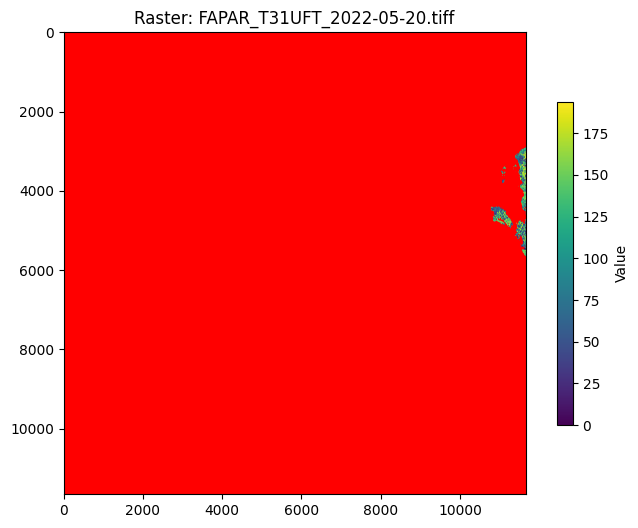

In [4]:
path = "../data/LAI_FAPAR/FAPAR_T31UFT_2022-05-20.tiff"
inspect_tiff(path)

File: ../data/LAI_FAPAR_temporal_filled/FAPAR_T31UFT_2022-05-20_filled_temporal.tiff
Total pixels: 135,943,938
NaN count: 0 (0.00%)
Zero count: 4,852,179 (3.57%)
Min: 0.000, Max: 195.000, Mean: 100.309


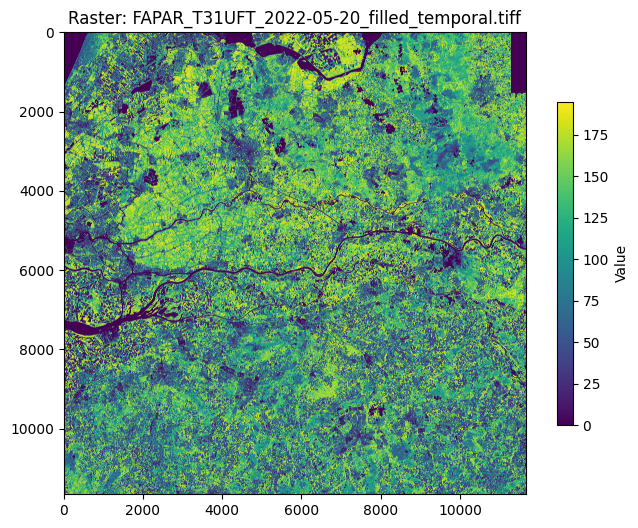

In [5]:
path = "../data/LAI_FAPAR_temporal_filled/FAPAR_T31UFT_2022-05-20_filled_temporal.tiff"
inspect_tiff(path)